# [기초-실습] 통계 101x데이터 분석: (5-6장) 다양한 가설검정

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!pip install statsmodels
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 24 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,223 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 
(Reading database ... 5%
(Reading database ... 10%
(Reading database ... 15%
(Reading database ... 20%
(Reading database ... 25%
(Reading database ... 30%
(Reading database ... 35%
(Reading database ... 40%
(Reading database ... 45%
(Reading database ... 50%
(Reading database ... 55%
(Reading database ... 60%
(Reading database ... 65%
(Reading database ... 70%
(Reading database ... 75%
(Reading database ... 80%
(Reading database ... 85%
(Reading database ... 90%
(Reading database

In [11]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 문제 1. 게임 아이템 뽑기 확률, 정말 10%일까? (난이도: 하)

**📘 문제**

- 어떤 게임 개발사에서 새로운 아이템의 뽑기 확률이 **10%**로 설정되었다고 주장하고 있습니다.

- 그런데 유저 커뮤니티에서는 "실제 확률은 10%보다 낮은 것 같다"는 의혹이 제기되었습니다.

- 이를 확인하기 위해 한 유저가 아이템을 **200번 뽑았고, 그중 12번 성공**했습니다.

- 이번 실습에서는 **이항검정(Binomial Test)**으로 이 결과가 개발사의 주장을 기각할 만큼 유의미한지 확인하고,
  시뮬레이션을 통해 **p-값이 무엇을 의미하는지**를 직접 눈으로 확인해 봅니다.

In [2]:
# 문제 설정
n = 200  # 총 시행 횟수
x = 12   # 관찰된 성공 횟수
p = 0.1  # 귀무가설에서의 성공 확률

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")

관찰 결과: 200번 시도 중 12번 성공 (관찰 성공률 6.0%)


**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 이항검정을 수행하여 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"만약 개발사의 주장대로 실제 확률이 정말 10%라면"** 200번 뽑기에서 성공 횟수가 어떻게 분포하는지 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 우리가 관찰한 '12번 성공'이 얼마나 희귀한 일인지 관찰해 봅시다.

In [12]:
# [문제 1] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.

# H₀ (귀무가설): 게임 아이템 뽑기 확률은 10%이다. p=0.1
# H₁ (대립가설): 게임 아이템 뽑기 확률은 10%보다 낮다. p<0.1

In [14]:
# [문제 1] Q2. 이항검정을 수행하고 p-값을 계산해봅시다.
# '확률이 더 낮은 것 같다'는 주장을 검증하려면 alternative 인수를 어떻게 설정해야 할까요?

from scipy.stats import binomtest

result = binomtest(x, n=n, p=p, alternative="less")
print(f"p-value = {result.pvalue:.4f}")

p-value = 0.0320


In [15]:
# [문제 1] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각합니다.")
else:
    print("귀무가설을 기각하지 못합니다.")

귀무가설을 기각합니다.


In [16]:
# [문제 1] Q4. H₀가 사실(실제 확률 = 10%)이라고 가정하고,
# 200번 뽑기를 10,000번 반복하는 시뮬레이션을 수행해봅시다.
# 힌트: numpy의 이항분포 랜덤 함수(np.random.binomial)를 사용해보세요.

import numpy as np

np.random.seed(42)

simulations = np.random.binomial(n=n, p=p, size=10000)

print(simulations)

[19 27 23 ... 27 19 17]


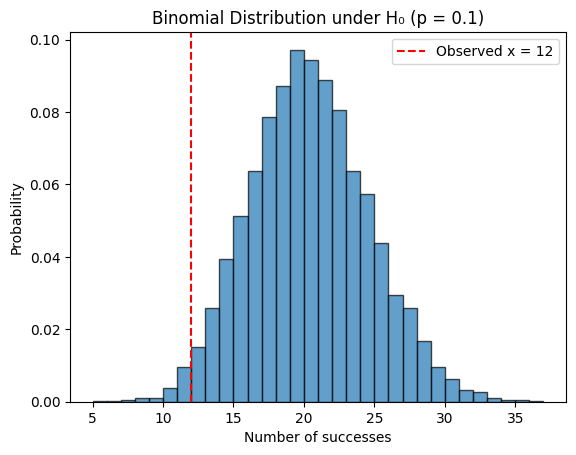

In [13]:
# [문제 1] Q5. 시뮬레이션 결과를 히스토그램으로 그려봅시다.
# 실제 관찰값(12번 성공)을 세로선으로 함께 표시해 봅시다.

import numpy as np
import matplotlib.pyplot as plt

# 문제 설정
n = 200
x = 12
p = 0.1

# 귀무가설 하에서 10,000번 시뮬레이션
np.random.seed(42)
sim = np.random.binomial(n, p, size=10000)

# 히스토그램
plt.hist(sim, bins=range(sim.min(), sim.max() + 2),
         density=True, edgecolor="black", alpha=0.7)

# 실제 관찰값 표시
plt.axvline(x, color="red", linestyle="--", label=f"Observed x = {x}")

plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.title("Binomial Distribution under H₀ (p = 0.1)")
plt.legend()
plt.show()

# H₀ (귀무가설): 게임 아이템 뽑기 확률은 10%이다. p=0.1
# H₁ (대립가설): 게임 아이템 뽑기 확률은 10%보다 낮다. p<0.1

**🧠 데이터를 어떻게 읽을까요?**

- Q2에서 구한 p-값은 시뮬레이션 그래프의 어느 부분에 해당하며, 무엇을 의미하나요?

- 시뮬레이션 그래프를 볼 때, 우리가 관찰한 '12회 성공'은 개발사의 주장이 맞다는 가정 하에 흔한 일인가요, 드문 일인가요?

- 이 시뮬레이션 경험을 통해 "p-값이 작으면 귀무가설을 기각한다"는 규칙을 친구에게 어떻게 더 쉽게 설명할 수 있을까요?

- 만약 200번이 아니라 1,000번을 뽑아 같은 성공률(6%)이 나왔다면, p-값은 어떻게 달라질까요?

In [10]:
# [문제 1] 데이터를 어떻게 읽을까요?

# 관측값이 시뮬레이션 그래프의 점선 좌측에 위치하며, 점선(기각역)보다 작아, 귀무가설이 참이라고 가정했을 때, 12회 이하가 나올 확률을 의미함.
# 귀무가설의 관점에서 보자면 200회 뽑기 시 12회 성공은 드문 일임.
# 개발사가 주장한 10%와 달리 우리가 실험한 6% 확률이 p-값이고, 이건 우연이라고 보기 어렵기 때문에 드문 일이라 판단하고 귀무가설을 기각하는 것임.

from scipy.stats import binomtest
result200 = binomtest(12, n=200, p=0.1, alternative="less")
print(result200.pvalue)
result1000 = binomtest(60, n=1000, p=0.1, alternative="less")
print(result1000.pvalue)

# 효과 크기가 같더라도 표본 수가 많아지면 우연에 의한 변동 가능성이 줄어들기 때문에 p-값이 작아짐.
# 과학적 표기법(scientific notation)이 아닌 실수로 표현하면 0.00000438임.

0.0320465287969066
4.378819902862752e-06


# 문제 2. 과자 한 봉지의 중량은 150g이 맞을까? (난이도: 하)

**📘 문제**

- 한 식품 공장에서 생산하는 과자 한 봉지의 **목표 중량은 150g**입니다.

- 품질관리팀은 생산 공정이 목표 중량을 잘 맞추고 있는지 확인하기 위해,
  생산된 과자 **30봉지를 무작위로 추출**하여 무게를 측정했습니다.

- 이번 실습에서는 **일표본 t-검정(One-sample t-Test)**으로 표본 평균이 목표 중량과 유의미하게 다른지 검증하고,
  **"평균이 정확히 150g이라면"** 어떤 표본 평균들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

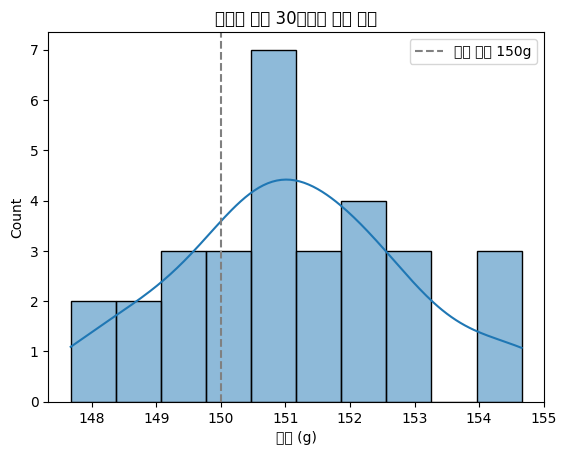

In [3]:
# 데이터 생성 (과자 30봉지의 무게 측정값)
np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150  # 목표 중량 (모평균)

# 표본 분포 시각화
sns.histplot(sample_weights, bins=10, kde=True)
plt.axvline(x=pop_mean, color='gray', linestyle='--', label='목표 중량 150g')
plt.title("추출한 과자 30봉지의 무게 분포")
plt.xlabel("무게 (g)")
plt.legend()
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 일표본 t-검정을 수행하여 t-통계량과 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"평균 무게가 정확히 150g이라면"** 30개짜리 표본의 평균이 어떻게 분포하는지 10,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 표본 평균이 그 분포에서 어디에 위치하는지 관찰해 봅시다.

In [4]:
print(sample_weights.mean(), sample_weights.std(ddof=1))

In [18]:
# [문제 2] Q2. 일표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.

from scipy.stats import ttest_1samp

t_stat, p_value = ttest_1samp(sample_weights, popmean=pop_mean)

print(f"t-통계량 = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")

t-통계량 = 3.4193
p-value = 0.0019


In [17]:
# [문제 2] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

alpha = 0.05

if p_value < alpha:
    print("귀무가설을 기각합니다.")
else:
    print("귀무가설을 기각하지 못합니다.")

귀무가설을 기각합니다.


In [19]:
# [문제 2] Q4. H₀가 사실(평균 = 150g)이라고 가정하고, 30개짜리 표본을 10,000번 뽑아
# 각 표본의 평균을 리스트에 저장해봅시다.
# 힌트: 표준편차는 우리가 가진 표본의 표준편차를 사용한다고 가정하고, for 반복문을 사용해보세요.

sample_std = np.std(sample_weights, ddof=1)

sim_means = []

for i in range(10000):
    sample = np.random.normal(loc=pop_mean, scale=sample_std, size=30)
    sim_means.append(np.mean(sample))

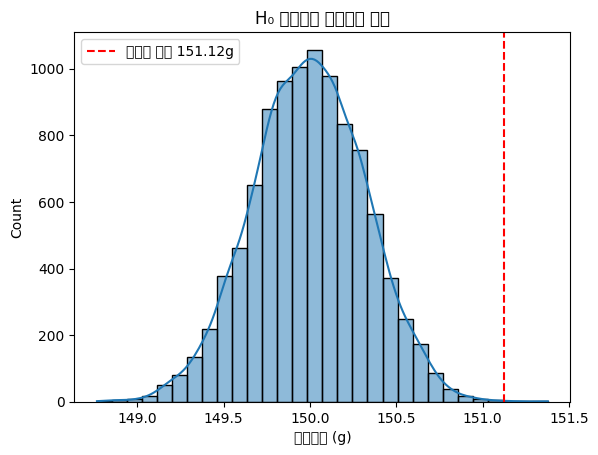

In [20]:
# [문제 2] Q5. 시뮬레이션으로 얻은 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 표본 평균을 세로선으로 함께 표시해 봅시다.

observed_mean = np.mean(sample_weights)

sns.histplot(sim_means, bins=30, kde=True)

plt.axvline(observed_mean, color="red", linestyle="--",
            label=f"관찰된 평균 {observed_mean:.2f}g")

plt.title("H₀ 하에서의 표본평균 분포")
plt.xlabel("표본평균 (g)")
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- Q5의 히스토그램은 무엇을 나타내나요? 이 분포의 모양이 정규분포와 비슷한 이유는 무엇일까요? (힌트: 4장에서 배운 중심극한정리)

- 우리가 실제로 관찰한 표본 평균(세로선)은 이 분포에서 흔하게 나타나는 값인가요? Q2의 p-값과 이 시각적 위치는 어떻게 관련되나요?

- 만약 p-값이 0.001이었다면, 세로선은 그래프의 어디쯤에 위치할 것으로 예상되나요?

- 이 결과는 공장 입장에서 어떤 조치를 취해야 함을 시사할까요? (목표보다 무겁게 나오는 것은 어떤 손실일까요?)

In [21]:
# [문제 2] 데이터를 어떻게 읽을까요?

# 히스토그램은 표본평균 1만 개의 분포를 나타내며, 표본 하나가 30개 값의 평균이라 개별 값의 변동이 서로 상쇄되고, 따라서 표본평균의 분포가 정규분포 모양이 됨.
# p-값은 유의수준보다 작아 귀무가설을 기각하기에 충분하며, 세로선 역시 우측 극단에 위치해있음.
# p-값이 0.001일 경우더라도 현재의 p-값 0.0019와 큰 차이가 없으며, 현재의 세로선보다 약소하게 바깥쪽에 위치할 것임.
# 목표보다 무겁게 나오는 것은 일부 원재료 등 손실이 있을 수 있으며, 생산제품이 목표보다 무겁게 치우쳐 있다는 통계적 근거가 있으므로 공정 라인 점검이 필요함.

# 문제 3. 어떤 온라인 학습 방식이 더 효과적일까? (난이도: 중)

**📘 문제**

- 한 교육 기업에서 두 가지 다른 온라인 학습 방식(A, B)을 개발했습니다.

- 방식 A가 방식 B보다 학생들의 성적 향상에 더 효과적인지 알아보기 위해,
  두 그룹의 학생들에게 각각 다른 방식으로 한 달간 학습시킨 후 시험을 보게 했습니다.

- 이번 실습에서는 **이표본 t-검정(Two-sample t-Test)**으로 두 방식의 평균 점수 차이를 검증합니다.
  단, t-검정의 기본 가정인 **정규성**과 **등분산성**을 먼저 확인해야 합니다.

- 또한 **"두 방식의 효과가 완전히 똑같다면"** 우연히 나타날 수 있는 점수 차이의 범위를 시뮬레이션으로 확인해 봅니다.

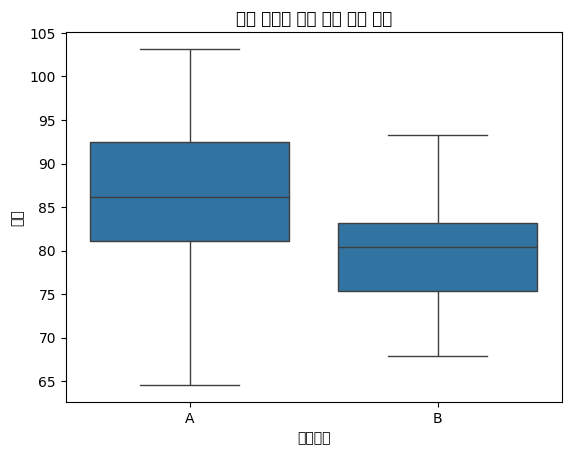

In [5]:
# 데이터 생성 (두 학습 방식의 시험 점수)
np.random.seed(0)
group_a_scores = np.random.normal(loc=85, scale=8, size=50)
group_b_scores = np.random.normal(loc=80, scale=7, size=50)

df_scores = pd.DataFrame({'점수': np.concatenate([group_a_scores, group_b_scores]),
                          '학습방식': ['A']*50 + ['B']*50})

# 두 그룹의 점수 분포 시각화
sns.boxplot(x='학습방식', y='점수', data=df_scores)
plt.title("학습 방식에 따른 시험 점수 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 두 그룹에 대해 **정규성 검정(Shapiro-Wilk test)**을 수행해 봅시다. (H₀: 데이터는 정규분포를 따른다.)

- **등분산성 검정(Levene's test)**을 수행해 봅시다. (H₀: 두 그룹의 분산은 같다.)

- 가정 검토 결과에 따라 `equal_var` 인수를 설정하여 **이표본 t-검정**을 수행해 봅시다.

- 두 그룹 데이터를 모두 합친 뒤 무작위로 다시 나누는 방식으로, **"두 방식의 효과가 같을 때"**의 평균 차이 분포를 시뮬레이션해 봅시다.

In [22]:
# [문제 3] Q1. 두 그룹에 대해 각각 정규성 검정(Shapiro-Wilk test)을 수행하고 p-값을 출력해봅시다.
# H₀: 데이터는 정규분포를 따른다.

from scipy.stats import shapiro

stat_a, p_a = shapiro(group_a_scores)
stat_b, p_b = shapiro(group_b_scores)

print(f"[A그룹 Shapiro-Wilk 검정]")
print(f"검정통계량 = {stat_a:.4f}, p-value = {p_a:.4f}")

print(f"\n[B그룹 Shapiro-Wilk 검정]")
print(f"검정통계량 = {stat_b:.4f}, p-value = {p_b:.4f}")

[A그룹 Shapiro-Wilk 검정]
검정통계량 = 0.9876, p-value = 0.8766

[B그룹 Shapiro-Wilk 검정]
검정통계량 = 0.9866, p-value = 0.8366


In [23]:
# [문제 3] Q2. 두 그룹에 대해 등분산성 검정(Levene's test)을 수행하고 p-값을 출력해봅시다.
# H₀: 두 그룹의 분산은 같다.

from scipy.stats import levene

lev_stat, lev_p = levene(group_a_scores, group_b_scores)

print("[Levene 등분산성 검정]")
print(f"검정통계량 = {lev_stat:.4f}, p-value = {lev_p:.4f}")

if lev_p > 0.05:
    print("등분산 가정을 기각하지 못합니다.")
else:
    print("등분산 가정을 기각합니다.")

[Levene 등분산성 검정]
검정통계량 = 6.1330, p-value = 0.0150
등분산 가정을 기각합니다.


In [24]:
# [문제 3] Q3. 이표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.
# H₀: 두 그룹의 평균은 같다. / H₁: 두 그룹의 평균은 다르다.
# 등분산성 가정을 만족했는지 여부에 따라 equal_var 인수를 설정해보세요.

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group_a_scores, group_b_scores, equal_var=False)

print(f"t-통계량 = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")

t-통계량 = 4.0426
p-value = 0.0001


In [26]:
# [문제 3] Q4. H₀가 사실(두 그룹의 평균이 같다)이라고 가정하고 시뮬레이션을 10,000번 수행해봅시다.
# 두 그룹의 데이터를 모두 합친 뒤(np.concatenate), 매 반복마다 비복원추출로 50개(가상 A그룹)와
# 나머지 50개(가상 B그룹)로 나누어 두 그룹의 평균 차이를 계산하고 리스트에 저장해보세요.
# 힌트: np.random.permutation 을 사용해보세요.

combined_scores = np.concatenate([group_a_scores, group_b_scores])

sim_diffs = []

for i in range(10000):
    shuffled = np.random.permutation(combined_scores)
    sim_a = shuffled[:50]
    sim_b = shuffled[50:]
    
    sim_diffs.append(np.mean(sim_a) - np.mean(sim_b))

print(f"시뮬레이션 평균 차이의 평균: {np.mean(sim_diffs):.4f}")
print(f"처음 5개 평균 차이: {[round(x, 4) for x in sim_diffs[:5]]}")

시뮬레이션 평균 차이의 평균: -0.0053
처음 5개 평균 차이: [np.float64(0.4815), np.float64(0.2831), np.float64(-0.0105), np.float64(0.5302), np.float64(0.4219)]


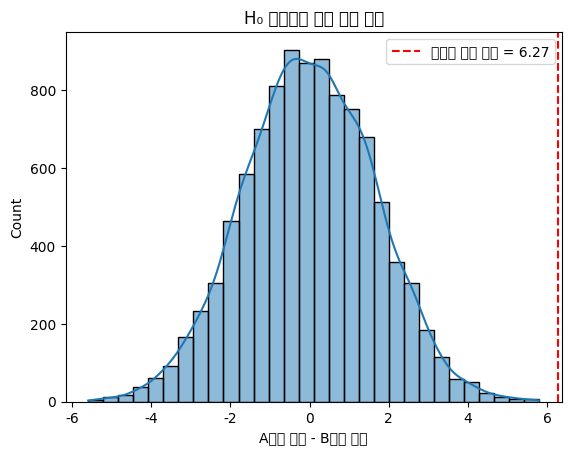

In [25]:
# [문제 3] Q5. 시뮬레이션으로 얻은 평균 차이의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 평균 차이(A그룹 평균 - B그룹 평균)를 세로선으로 함께 표시해 봅시다.

observed_diff = np.mean(group_a_scores) - np.mean(group_b_scores)

sns.histplot(sim_diffs, bins=30, kde=True)

plt.axvline(observed_diff, color="red", linestyle="--",
            label=f"관찰된 평균 차이 = {observed_diff:.2f}")

plt.title("H₀ 하에서의 평균 차이 분포")
plt.xlabel("A그룹 평균 - B그룹 평균")
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 정규성 검정과 등분산성 검정의 p-값은 각각 어떻게 해석해야 하나요? 이 결과는 이표본 t-검정을 사용하는 데 문제가 없음을 보여주나요?

- Q5의 히스토그램 중심이 0에 가까운 이유는 무엇일까요?

- 실제 관찰된 평균 차이(세로선)는 "두 방식의 효과가 같다"고 가정했을 때 우연히 나타날 수 있는 범위 안에 있나요, 벗어나나요?

- 이 시각적 판단과 Q3의 p-값은 어떤 관계가 있나요?

- 통계적으로 유의미한 차이가 있다면, 교육 기업은 이 결과를 어떻게 활용할 수 있을까요?

In [27]:
# [문제 3] 데이터를 어떻게 읽을까요?

# 이표본 t검정은 정규성과 등분산성을 모두 충족해야 하나, 본 데이터는 정규성만을 만족하고 등분산성이 기각되었으므로 이표본 t검정 대신 Welch의 t-검정을 사용해야 적절함.
# 히스토그램 중심이 0에 가까운 이유는 두 집단의 평균이 같다는 가정 하에 만든 것이기 때문임.
# 평균 차이(세로선)는 6.27로 우연의 범위를 크게 벗어남.
# p-값은 0.0001로 유의수준 0.05보다 작으며, 평균(세로선)이 중심선 0에서 벗어났으므로 두 그룹의 평균이 같다고 볼 수 없음.
# 교육 기업은 본 결과를 통해 평균점수가 높은 그룹의 방식을 다른 그룹에 활용할 수 있음.

# 문제 4. 연령대별로 선호하는 영화 장르가 다를까? (난이도: 중)

**📘 문제**

- 한 영화관에서 고객의 **연령대(20대, 30대, 40대)**에 따라 선호하는 **영화 장르(액션, 로맨스)**에 차이가 있는지 궁금해졌습니다.

- 이를 알아보기 위해 300명의 고객을 대상으로 설문조사를 진행하여 분할표를 얻었습니다.

- 이번 실습에서는 **카이제곱 독립성 검정(Chi-squared Test of Independence)**으로
  두 범주형 변수 사이에 연관성이 있는지 검증합니다.

- 또한 **"두 변수가 서로 아무 관련이 없다면(독립이라면)"** 어떤 카이제곱 통계량들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

관측 빈도 (Observed Frequencies):
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60


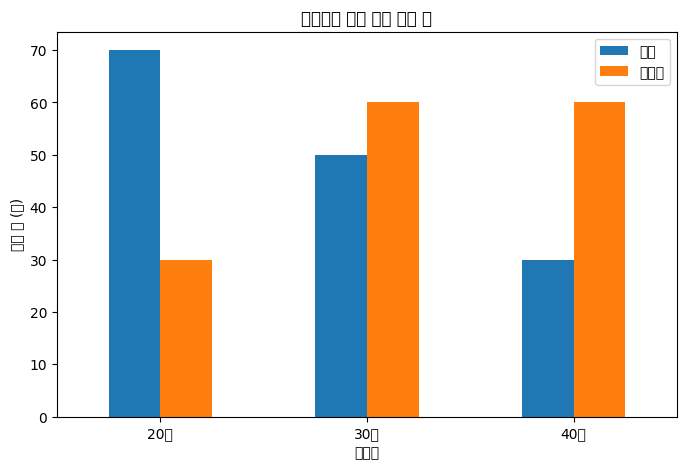

In [6]:
# 데이터 생성 (관측 빈도 분할표)
data = {'액션': [70, 50, 30],
        '로맨스': [30, 60, 60]}
observed = pd.DataFrame(data, index=['20대', '30대', '40대'])

print("관측 빈도 (Observed Frequencies):")
print(observed)

# 분할표 시각화
observed.plot(kind='bar', figsize=(8, 5))
plt.title("연령대별 선호 장르 응답 수")
plt.xlabel("연령대")
plt.ylabel("응답 수 (명)")
plt.xticks(rotation=0)
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 카이제곱 독립성 검정을 수행하여 카이제곱 통계량, p-값, 자유도, **기대 빈도**를 구해봅시다.

- **"연령대와 선호 장르가 독립이라면"** 어떤 분할표들이 나타날 수 있는지 5,000번 시뮬레이션해 봅시다.

- 시뮬레이션으로 얻은 카이제곱 통계량 분포와 실제 관찰된 카이제곱 통계량을 비교해 봅시다.

In [28]:
# [문제 4] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 연령대(20대, 30대, 40대)에 따라 선호하는 영화 장르(액션, 로맨스)에 차이가 없다.
# H₁ (대립가설): 연령대(20대, 30대, 40대)에 따라 선호하는 영화 장르(액션, 로맨스)에 차이가 있다.

In [29]:
# [문제 4] Q2. 카이제곱 독립성 검정을 수행하고 카이제곱 통계량, p-값, 자유도, 기대 빈도를 구해봅시다.
# 기대 빈도는 관측 빈도와 비교하기 쉽도록 데이터프레임 형태로 출력해보세요.

from scipy import stats

chi2, p_value, dof, expected = stats.chi2_contingency(observed)

expected_df = pd.DataFrame(
    expected,
    index=observed.index,
    columns=observed.columns
)

print("[카이제곱 독립성 검정]")
print(f"카이제곱 통계량 = {chi2:.2f}")
print(f"p-value = {p_value:.6f}")
print(f"자유도 = {dof}")

print("\n기대 빈도 (Expected Frequencies):")
print(expected_df)

[카이제곱 독립성 검정]
카이제곱 통계량 = 26.91
p-value = 0.000001
자유도 = 2

기대 빈도 (Expected Frequencies):
       액션   로맨스
20대  50.0  50.0
30대  55.0  55.0
40대  45.0  45.0


In [30]:
# [문제 4] Q3. H₀가 사실(두 변수가 독립)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 각 반복마다 300명의 가상 고객에게 연령대와 장르를 '독립적으로' 할당한 후,
# 가상 분할표를 만들고 카이제곱 통계량을 계산하여 리스트에 저장해보세요.
# 힌트 1: 전체 비율(observed.sum(axis=0) / 전체, observed.sum(axis=1) / 전체)을 확률로 사용
# 힌트 2: np.random.choice 로 300명의 연령대와 장르를 각각 독립적으로 생성
# 힌트 3: pd.crosstab 으로 분할표 생성 후 stats.chi2_contingency 로 통계량 계산

np.random.seed(0)

total = observed.values.sum()

age_probs = observed.sum(axis=1) / total
genre_probs = observed.sum(axis=0) / total

sim_chi2 = []

for i in range(5000):
    ages = np.random.choice(observed.index, size=300, p=age_probs)
    genres = np.random.choice(observed.columns, size=300, p=genre_probs)

    sim_table = pd.crosstab(ages, genres).reindex(
        index=observed.index,
        columns=observed.columns,
        fill_value=0
    )

    chi2_sim, _, _, _ = stats.chi2_contingency(sim_table)
    sim_chi2.append(chi2_sim)

print(f"시뮬레이션 횟수: {len(sim_chi2)}")
print(f"시뮬레이션 카이제곱 통계량 평균: {np.mean(sim_chi2):.2f}")
print(f"처음 5개 통계량: {[round(x, 2) for x in sim_chi2[:5]]}")

시뮬레이션 횟수: 5000
시뮬레이션 카이제곱 통계량 평균: 2.04
처음 5개 통계량: [np.float64(3.12), np.float64(8.82), np.float64(3.18), np.float64(1.77), np.float64(1.21)]


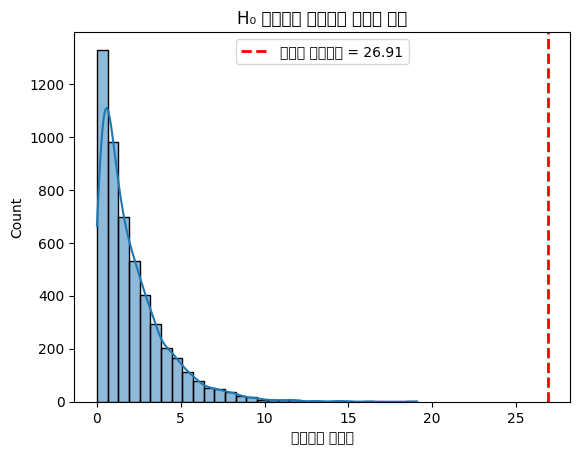

In [31]:
# [문제 4] Q4. 시뮬레이션으로 얻은 카이제곱 통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 카이제곱 통계량을 세로선으로 함께 표시해 봅시다.

sns.histplot(sim_chi2, bins=30, kde=True)

plt.axvline(x=chi2, color="red", linestyle="--", linewidth=2,
            label=f"관찰된 카이제곱 = {chi2:.2f}")

plt.title("H₀ 하에서의 카이제곱 통계량 분포")
plt.xlabel("카이제곱 통계량")
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- '기대 빈도'는 어떤 의미를 가지며, '관측 빈도'와의 차이가 클수록 카이제곱 통계량은 어떻게 변할까요?

- Q4의 히스토그램은 어떤 분포를 시각화한 것인가요? 실제 관찰된 카이제곱 통계량(세로선)은 흔한 값인가요, 극단적인 값인가요?

- 유의수준 0.05에서, 연령대와 선호 장르 사이에 통계적으로 유의미한 연관성이 있다고 결론 내릴 수 있나요? 그 이유는 무엇인가요?

- 이 결과를 바탕으로 영화관은 연령대별로 어떤 상영 전략이나 프로모션을 세울 수 있을까요?

In [32]:
# [문제 4] 데이터를 어떻게 읽을까요?

# 기대 빈도는 연령대와 선호 장르가 독립이라는 가정 하에서의 예상되는 빈도이며, 관측 빈도와의 차이가 클수록 카이제곱 통계량도 커짐.
# 히스토그램은 귀무가설 하에서의 카이제곱 통계량 분포를 시각화한 것이며, 관찰된 카이제곱 통계량은 매우 극단적인 값임.
# 카이제곱 독립성 검정에 따른 실제 관측된 p-값은 0.000001로 유의수준 보다 한참 작아 통계적으로 유의미한 연관성이 있다고 볼 수 있음.

(observed - expected) / np.sqrt(expected)

# 조사 결과는 연령대별 차등 라인업 및 프로모션 구성의 근거를 보여주었으며, 영화관은 연령대별 영화관 방문 데이터 등을 추가 조사하여 해당 시간에 맞는 장르를 토대로 스크린을 확보하여 상영시간표를 구성할 수 있음.

           액션       로맨스
20대  2.828427 -2.828427
30대 -0.674200  0.674200
40대 -2.236068  2.236068


# 문제 5. 미니 프로젝트 - 어떤 신규 비료가 가장 효과적일까? (난이도: 상)

**📘 문제**

- 한 농업 연구소에서 새로 개발한 비료 3종류(A, B, C)의 생산량 증대 효과를 비교하고자 합니다.

- 동일한 조건의 밭 30개를 준비하여, 각각 10개씩 비료 A, B, C를 투여한 후 수확량을 측정했습니다.

- 이번 실습에서는 **분산분석(ANOVA)**으로 세 비료 간 평균 수확량에 차이가 있는지 검증하고,
  차이가 있다면 **사후분석(Tukey's HSD)**으로 어떤 비료끼리 차이가 나는지 확인합니다.

- 마지막으로 **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량이 나올 수 있는지 시뮬레이션하고,
  분석 결과를 바탕으로 연구소에 어떤 비료를 추천할지까지 생각해 봅니다.

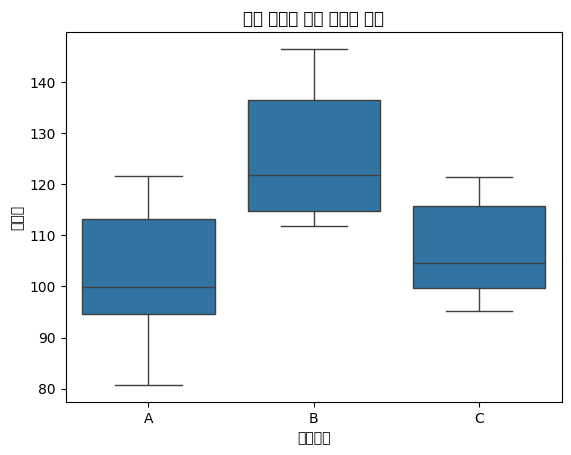

In [7]:
# 데이터 생성 (비료 종류별 수확량)
np.random.seed(123)
fertilizer_a = np.random.normal(loc=105, scale=10, size=10)
fertilizer_b = np.random.normal(loc=120, scale=12, size=10)
fertilizer_c = np.random.normal(loc=108, scale=9, size=10)

# 데이터프레임으로 변환 (사후분석을 위해)
df = pd.DataFrame({'수확량': np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c]),
                   '비료종류': ['A']*10 + ['B']*10 + ['C']*10})

# 데이터 탐색 시각화
sns.boxplot(x='비료종류', y='수확량', data=df)
plt.title("비료 종류에 따른 수확량 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 세 그룹에 대해 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.

- ANOVA 결과가 유의미할 경우에만 **Tukey's HSD 사후분석**을 수행하고 결과를 해석해 봅시다.

- **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량들이 나오는지 5,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 F-통계량이 얼마나 극단적인 값인지 확인해 봅시다.

- 분석 결과를 종합하여 연구소에 추천할 비료를 정해 봅시다.

In [33]:
# [문제 5] Q1. 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.
# H₀: 세 비료의 평균 수확량은 모두 같다.
# H₁: 적어도 하나 이상의 비료 평균 수확량은 다르다.

from scipy import stats

f_stat, p_value = stats.f_oneway(
    fertilizer_a,
    fertilizer_b,
    fertilizer_c
)

print("[일원분산분석 ANOVA]")
print(f"F-통계량 = {f_stat:.2f}")
print(f"p-value = {p_value:.6f}")

[일원분산분석 ANOVA]
F-통계량 = 10.35
p-value = 0.000462


In [34]:
# [문제 5] Q2. ANOVA의 p-값이 유의수준 0.05보다 작을 경우에만
# Tukey's HSD 사후분석을 수행하고 결과를 출력해봅시다.
# 힌트: pairwise_tukeyhsd(endog=수확량, groups=비료종류, alpha=0.05)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

alpha = 0.05

if p_value < alpha:
    print("ANOVA 결과가 유의하므로 Tukey HSD 사후분석을 수행합니다.\n")
    
    tukey = pairwise_tukeyhsd(
        endog=df['수확량'],
        groups=df['비료종류'],
        alpha=0.05
    )
    
    print(tukey)
else:
    print("ANOVA 결과가 유의하지 않아 사후분석을 수행하지 않습니다.")

ANOVA 결과가 유의하므로 Tukey HSD 사후분석을 수행합니다.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  23.6754 0.0006  10.0402 37.3106   True
     A      C   4.8429 0.6569  -8.7923 18.4781  False
     B      C -18.8325 0.0054 -32.4677 -5.1972   True
-----------------------------------------------------


In [35]:
# [문제 5] Q3. H₀가 사실(세 그룹의 평균이 모두 같다)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 모든 데이터를 합친 평균과 표준편차를 가진 H₀ 모집단에서 10개씩 3개의 가상 그룹을 생성하고,
# 이 가상 그룹들로 ANOVA를 수행하여 F-통계량을 리스트에 저장해보세요.

all_data = np.concatenate([
    fertilizer_a,
    fertilizer_b,
    fertilizer_c
])

h0_mean = np.mean(all_data)
h0_std = np.std(all_data, ddof=1)

sim_f_stats = []

for i in range(5000):
    sim_a = np.random.normal(h0_mean, h0_std, size=10)
    sim_b = np.random.normal(h0_mean, h0_std, size=10)
    sim_c = np.random.normal(h0_mean, h0_std, size=10)

    sim_f, _ = stats.f_oneway(sim_a, sim_b, sim_c)
    sim_f_stats.append(sim_f)

print(f"H₀ 모집단 평균: {h0_mean:.2f}")
print(f"H₀ 모집단 표준편차: {h0_std:.2f}")
print(f"시뮬레이션 횟수: {len(sim_f_stats)}")
print(f"처음 5개 F-통계량: {[round(x, 2) for x in sim_f_stats[:5]]}")

H₀ 모집단 평균: 111.81
H₀ 모집단 표준편차: 15.77
시뮬레이션 횟수: 5000
처음 5개 F-통계량: [np.float64(0.32), np.float64(0.93), np.float64(0.17), np.float64(1.66), np.float64(2.42)]


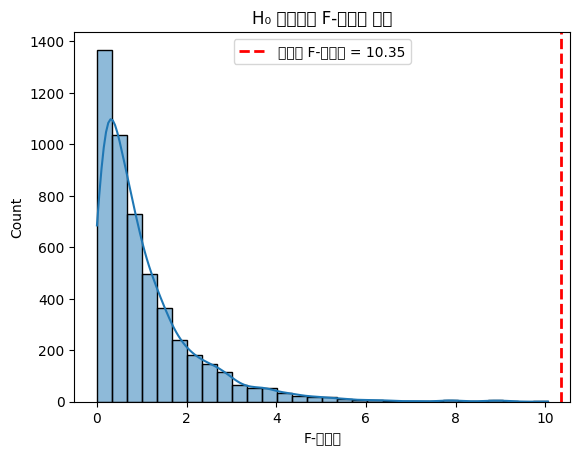

In [36]:
# [문제 5] Q4. 시뮬레이션으로 얻은 F-통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 F-통계량을 세로선으로 함께 표시해 봅시다.

sns.histplot(sim_f_stats, bins=30, kde=True)

plt.axvline(
    x=f_stat,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"관찰된 F-통계량 = {f_stat:.2f}"
)

plt.title("H₀ 하에서의 F-통계량 분포")
plt.xlabel("F-통계량")
plt.legend()
plt.show()

In [8]:
# [문제 5] Q5. 분석 결과를 바탕으로 연구소에 어떤 비료를 추천하시겠습니까?

# A, B, C 각 비료의 ANOVA 및 Tukey 사후분석 시행 결과, B 비료는 A, C 양쪽 모두와 평균수확량에서 통계적으로 유의한 차이를 보였으므로 B를 추천할 수 있을 것임.

**🧠 데이터를 어떻게 읽을까요?**

- ANOVA 검정의 p-값을 통해 어떤 결론을 내릴 수 있나요? 이 결과는 "세 비료가 모두 동일한 효과를 가진다"는 뜻인가요, "적어도 하나는 다르다"는 뜻인가요?

- Tukey's HSD 결과표의 `reject` 열에서 `True`로 표시된 조합은 무엇이며, 이는 무엇을 의미하나요?

- `meandiff` 열의 값은 어떤 정보를 주나요? 신뢰구간(`lower`, `upper`)이 0을 포함하는지 여부는 무엇을 뜻할까요?

- 그룹별 표본 크기가 10개로 작다는 점은 이 결론의 신뢰도에 어떤 영향을 줄까요? 어떻게 개선할 수 있을까요?

In [9]:
# [문제 5] 데이터를 어떻게 읽을까요?

# ANOVA 검정은 독립변인이 하나인 경우 그 독립변인의 수준(집단)에 따라 종속변인의 평균값에 차이가 있는지를 검증하는 통계적 방법으로, p-값이 작아 기각하였으니, 적어도 하나는 다르다는 의미를 가짐.
# reject 열에서 True로 표시된 조합은 A와 B, B와 C 조합이며, A와 C는 특별한 차이를 찾지 못했으며, B는 확실히 다르다는 것을 의미함.
# meandiff 열은 두 그룹의 평균 차이며, 추정값의 불확실성을 신뢰구간을 통해 보여줌.
# 해당 신뢰구간이 0을 포함한다면 실제 차이가 0일 가능성을 배제할 수 없으므로, 두 그룹이 다르다고 말할 수 없다는 근거임.
# 그룹별 표본이 충분히 크지 않을 경우 신뢰도구간이 넓어져 신뢰도에 영향을 줄 수 있으며, 표본을 충분히 크게 하여 정밀한 검증이 필요할 것임.